In [69]:
import numpy as np
from sklearn.linear_model import LinearRegression,LogisticRegression

x=np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y_reg=np.array([30,40,45,55,65,70,80,90])
y_cls=np.array([0,0,0,0,1,1,1,1])

log =LogisticRegression()
log.fit(x,y_cls)
print('Regression output:',log.predict_proba([[0.73]]))



Regression output: [[0.98799263 0.01200737]]


In [70]:
lin =LinearRegression()
lin.fit(x,y_reg)
print('Regression output:',lin.predict([[0.73]]))

Regression output: [27.73392857]


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1044/3813318023.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, prob, color='steelblue', linewidth=2.5, label='$\sigma(z)$')
/tmp/ipykernel_1044/3813318023.py:16: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma(z)$ = probability')


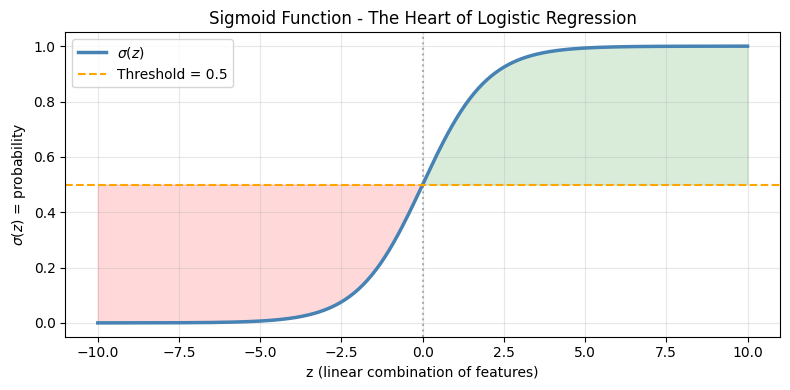

sigmoid(0) = 0.5000
sigmoid(5) = 0.9933
sigmoid(-5) = 0.0067


In [71]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1/(1+np.exp(-z))

z=np.linspace(-10,10,300)
prob = sigmoid(z)
plt.figure(figsize=(8, 4))
plt.plot(z, prob, color='steelblue', linewidth=2.5, label='$\sigma(z)$')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Threshold = 0.5')
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.6)
plt.fill_between(z, prob, 0.5, where=(prob > 0.5), alpha=0.15, color='green')
plt.fill_between(z, prob, 0.5, where=(prob < 0.5), alpha=0.15, color='red')
plt.xlabel('z (linear combination of features)')
plt.ylabel('$\sigma(z)$ = probability')
plt.title('Sigmoid Function - The Heart of Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'sigmoid(0) = {sigmoid(0):.4f}')
print(f'sigmoid(5) = {sigmoid(5):.4f}')
print(f'sigmoid(-5) = {sigmoid(-5):.4f}')

In [72]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=500, n_features=5,
weights=[0.7, 0.3],
  random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
model=LogisticRegression()
model.fit(X_train,y_train)
prob=model.predict_proba(X_test)[:,1]


In [74]:
print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>6}')
print('_' * 45)

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:


    preds = (prob >= threshold).astype(int)

    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds, zero_division=0)

    print(f'{threshold:>10.1f} {p:>10.3f} {r:>8.3f} {f:>6.3f}')

 Threshold  Precision   Recall     F1
_____________________________________________
       0.2      0.696    0.941  0.800
       0.3      0.762    0.941  0.842
       0.4      0.882    0.882  0.882
       0.5      0.882    0.882  0.882
       0.6      0.903    0.824  0.862
       0.7      0.903    0.824  0.862
       0.8      0.958    0.676  0.793


In [75]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [76]:
y_true=[1,1,1,1,1, 0,0,0,0,0, 1,0,1,0,1]
y_pred=[1,1,1,0,0, 0,0,0,1,1, 1,0,0,1,1]

In [77]:
y_true=np.array(y_true)
y_pred=np.array(y_pred)

In [78]:
TP=np.sum((y_true==1) & (y_pred==1)).sum()
TN=np.sum((y_true==0) & (y_pred==0)).sum()
FP=np.sum((y_true==0) & (y_pred==1)).sum()
FN=np.sum((y_true==1) & (y_pred==0)).sum()

In [79]:
print(f'TP={TP}, TN={TN}, FP={FP}, FN={FN}')

print(
    f'Accuracy = (TP+TN)/Total = '
    f'({TP}+{TN})/{len(y_true)} = '
    f'{(TP+TN)/len(y_true):.2f}'
)

print(
    f'Precision = TP/(TP+FP) = '
    f'{TP}/({TP}+{FP}) = '
    f'{TP/(TP+FP):.2f}'
)

print(
    f'Recall = TP/(TP+FN) = '
    f'{TP}/({TP}+{FN}) = '
    f'{TP/(TP+FN):.2f}'
)

TP=5, TN=4, FP=3, FN=3
Accuracy = (TP+TN)/Total = (5+4)/15 = 0.60
Precision = TP/(TP+FP) = 5/(5+3) = 0.62
Recall = TP/(TP+FN) = 5/(5+3) = 0.62


In [80]:
cm=confusion_matrix(y_true,y_pred)
print(cm)


[[4 3]
 [3 5]]


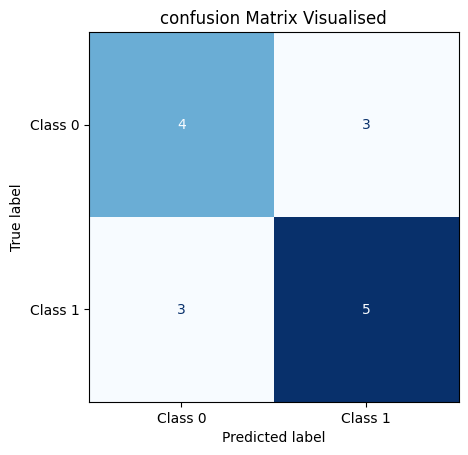

In [81]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues',colorbar=False)
plt.title('confusion Matrix Visualised');
plt.show()

In [82]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score,accuracy_score
import numpy as np

In [83]:
x_bal, y_bal = make_classification(n_samples=1000,weights=[0.5,0.5],random_state=1)

x_imb, y_imb = make_classification(n_samples=1000,weights=[0.99,0.01],random_state=1)

In [84]:
def evaluate(X, y, label):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f'\n=== {label} ===')

    print(f'Accuracy : {acc:.2%} <- {'MISLEADING!' if f1<0.5 else 'OK'}')
    print(f'F1 Score : {f1:.2%} <- Real performance')
    print(classification_report(y_test, y_pred, zero_division=0))

evaluate(x_bal, y_bal, 'Balanced')
evaluate(x_imb, y_imb, 'Imbalanced')


=== Balanced ===
Accuracy : 80.50% <- OK
F1 Score : 80.00% <- Real performance
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       106
           1       0.77      0.83      0.80        94

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.81       200


=== Imbalanced ===
Accuracy : 97.50% <- MISLEADING!
F1 Score : 0.00% <- Real performance
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.97      0.97       200



In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    x_imb, y_imb, test_size=0.2, random_state=42
)

model_fixed = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model_fixed.fit(X_train, y_train)

y_pred_fixed = model_fixed.predict(X_test)

print("\n=== After class_weight='balanced' ===")
print(classification_report(y_test, y_pred_fixed, zero_division=0))


=== After class_weight='balanced' ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       196
           1       0.04      0.25      0.07         4

    accuracy                           0.88       200
   macro avg       0.51      0.57      0.50       200
weighted avg       0.96      0.88      0.92       200



In [86]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [88]:
x,y=make_classification(n_samples=1000,n_features=10,random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
lr=LogisticRegression().fit(x_train,y_train)
probs_lr=lr.predict_proba(x_test)[:,1]
dt=DecisionTreeClassifier(max_depth=4).fit(x_train,y_train)
probs_dt=dt.predict_proba(x_test)[:,1]


In [91]:
fpr_lr,tpr_lr,_=roc_curve(y_test,probs_lr)
fpr_dt,tpr_dt,_=roc_curve(y_test,probs_dt)
auc_lr=roc_auc_score(y_test,probs_lr)
auc_dt=roc_auc_score(y_test,probs_dt)

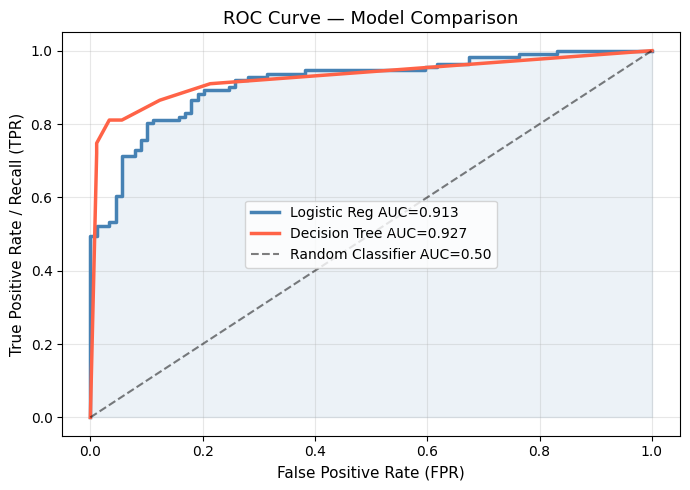

In [93]:
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, lw=2.5, color='steelblue', label=f'Logistic Reg AUC={auc_lr:.3f}')
plt.plot(fpr_dt, tpr_dt, lw=2.5, color='tomato', label=f'Decision Tree AUC={auc_dt:.3f}')
plt.plot([0,1],[0,1], 'k--', alpha=0.5, label='Random Classifier AUC=0.50')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=11)
plt.title('ROC Curve — Model Comparison', fontsize=13)
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08 

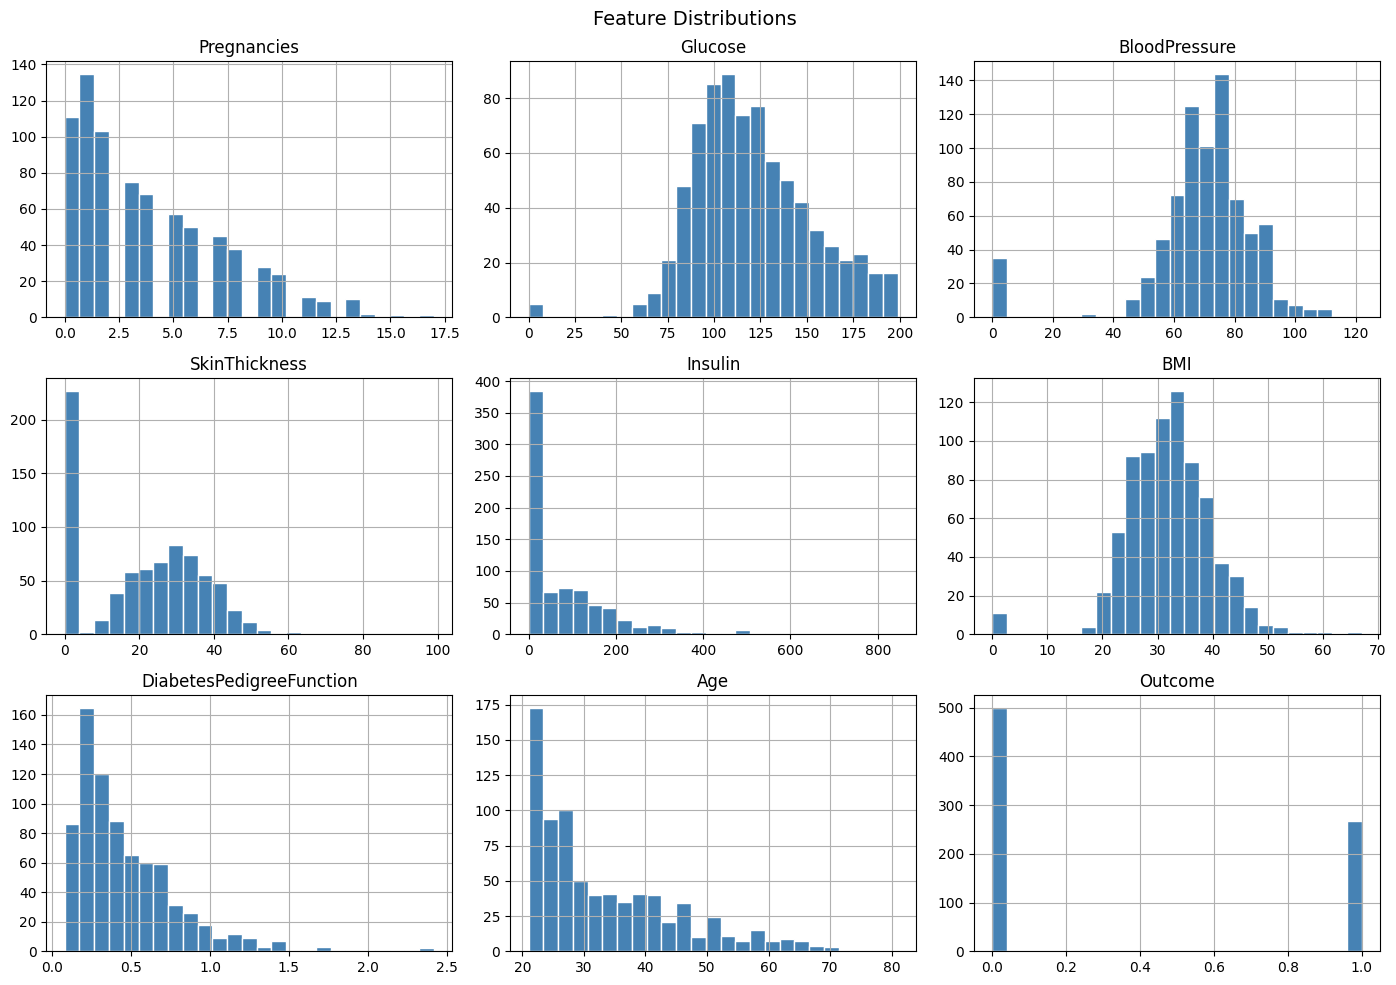

In [95]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

!test -f diabetes.csv || wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv')
print(df.shape)
print(df['Outcome'].value_counts())
print(df.describe().round(2))

df.hist(bins=25, figsize=(14,10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14); plt.tight_layout(); plt.show()

In [96]:
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols:
    n = (df[col] == 0).sum()
    df[col] = df[col].replace(0, df[col].median())
    print(f'{col:25s}: {n} zeros → replaced with median {df[col].median():.1f}')

Glucose                  : 5 zeros → replaced with median 117.0
BloodPressure            : 35 zeros → replaced with median 72.0
SkinThickness            : 227 zeros → replaced with median 23.0
Insulin                  : 374 zeros → replaced with median 31.2
BMI                      : 11 zeros → replaced with median 32.0


In [97]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
for name, coef in zip(X.columns, model.coef_[0]):
    print(f'{name:30s}: {coef:+.3f}')



fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols:
    n = (df[col] == 0).sum()
    df[col] = df[col].replace(0, df[col].median())
    print(f'{col:25s}: {n} zeros → replaced with median {df[col].median():.1f}')

Pregnancies                   : +0.376
Glucose                       : +1.209
BloodPressure                 : -0.054
SkinThickness                 : +0.029
Insulin                       : -0.133
BMI                           : +0.701
DiabetesPedigreeFunction      : +0.245
Age                           : +0.138
Glucose                  : 0 zeros → replaced with median 117.0
BloodPressure            : 0 zeros → replaced with median 72.0
SkinThickness            : 0 zeros → replaced with median 23.0
Insulin                  : 0 zeros → replaced with median 31.2
BMI                      : 0 zeros → replaced with median 32.0


              precision    recall  f1-score   support

     Healthy       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



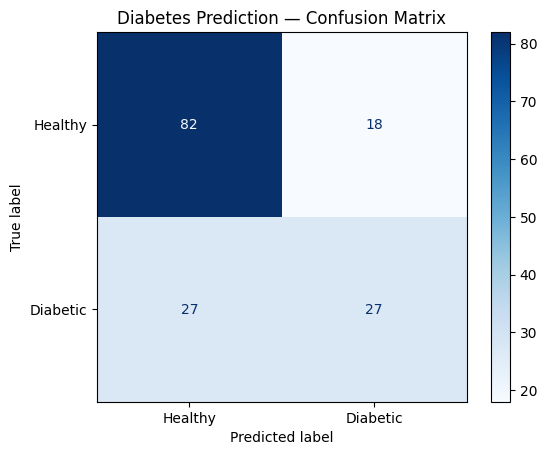

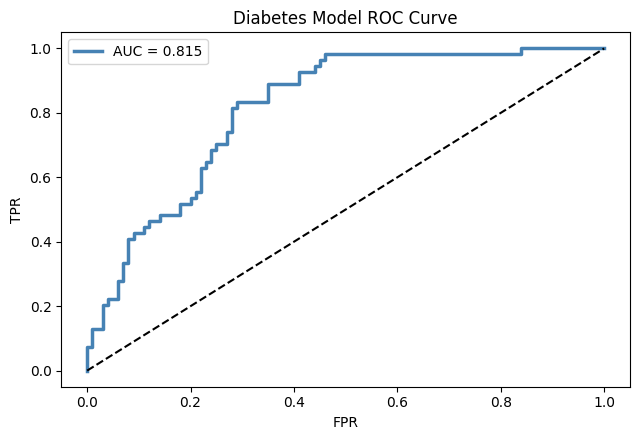

In [99]:

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Healthy','Diabetic']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(cmap='Blues')
plt.title('Diabetes Prediction — Confusion Matrix'); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6.5, 4.5))
plt.plot(fpr, tpr, lw=2.5, color='steelblue', label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Diabetes Model ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()


Prediction : Diabetic
Probability : 73.4% chance of having diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


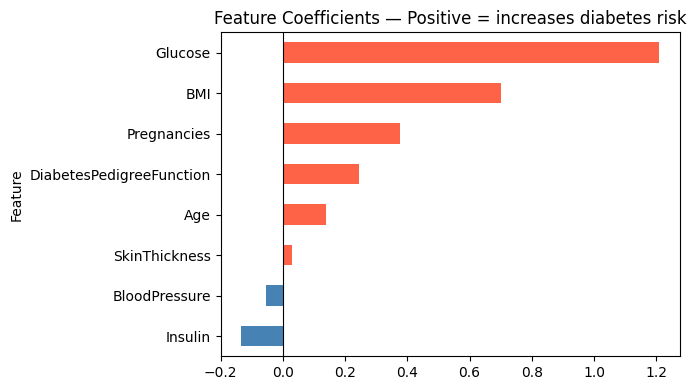

In [100]:

new_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
new_scaled = scaler.transform(new_patient)
pred = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0, 1]
print(f'Prediction : {'Diabetic' if pred==1 else 'Healthy'}')
print(f'Probability : {prob:.1%} chance of having diabetes')

import pandas as pd
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
color=['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']],
legend=False, figsize=(7, 4))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Positive = increases diabetes risk')
plt.tight_layout(); plt.show()